In [2]:
import numpy as np
import matplotlib.pyplot as plt
import design_space as ds
import constraint_coeff as cc
import code_variables as cv

class Engines:
    #initialize engine class
    def __init__(self,name,T_wet,weight):
        self.name = name
        self.T_wet = T_wet
        self.weight = weight
        self.T_W = T_wet/weight

AR = cv.AR_w
S = cv.S_w
c_f = cv.c_f
def calculate_zero_lift_drag_coefficient(c_f, S_wet, s_ref):
    return c_f * (S_wet / s_ref)
C_D_0 = cv.CD0
print("Zero-lift drag coefficient C_D_0:", C_D_0)

Zero-lift drag coefficient C_D_0: 0.01166


In [3]:
#https://www.rtx.com/en/prattwhitney/products/military-engines/f100
F100_229 = Engines("F100-229",29160,3826)

#https://www.mtu.de/engines/military-aircraft-engines/fighter-aircraft/f414/
F414 = Engines("F414",22000,2450)

#https://www.rtx.com/en/prattwhitney/products/military-engines/f135
F135 = Engines("F135",43000,6422)

##-----weights-------
num_pilot = cv.num_pilot
avg_wt_person = cv.avg_wt_person  #lb
aim_120c = cv.aim_120c #lb
aim_9x = cv.aim_9x #lb
mk_83jdam = cv.mk_83jdam#lb 
crew = cv.crew #lb
strike_payload = cv.strike_payload
W_crew = cv.W_crew
W_payload = cv.W_payload
print("W_payload: " + str(W_payload) + " lb")

W_payload: 4576 lb


In [4]:
# Fixed parameters for weight estimation
L_D_max = cv.L_D_max
R = cv.R            # nmi
E = cv.E            # min --> hr
ct_cruise = cv.ct_cruise    # lb/(lbf hr)
ct_dash = cv.ct_dash
v_cruise = cv.v_cruise      # knots
v_dash = cv.v_dash        # knots
S_ht = cv.S_ht
S_vt = cv.S_vt
S_wet_fuselage = cv.S_wet_fuselage
num_engines = cv.num_engines  # Example number of engines

# Aircraft Design Point
S_ZALKAS = 675 #ft^2
T_ZALKAS = 22000 * num_engines
EngineChosen = F414

# The value we can adjust by the constraint curve. For example, if we want to be on the takeoff constraint curve, we can find the corresponding W/S and then calculate the TOGW based on that W/S and the wing area.
S_wingtest = 700 #Changing to fit requirements
T_0 = EngineChosen.T_wet  # Example value for thrust per engine

TOGW_guess = 50000  # Initial guess for Takeoff Gross Weight in pounds

Inner Loop Iteration

In [5]:
##----Inner loop-----
def calculate_engine_weight(T_0):
    W_eng_dry = 0.521 * T_0**0.9
    W_eng_dry = EngineChosen.weight
    W_eng_oil = 0.082 * T_0**0.65
    W_eng_rev = 0.034 * T_0
    W_eng_control = 0.26 * T_0**0.5
    W_eng_start = 9.33 * (W_eng_dry/1000) ** 1.078
    W_eng = W_eng_dry + W_eng_oil + W_eng_rev + W_eng_control + W_eng_start
    #W_eng = 3826 # actual F100 weight (from https://www.rtx.com/en/prattwhitney/products/military-engines/f100)
    #W_eng= EngineChosen.weight
    return W_eng

def calculate_empty_weight(S_wing, S_ht, S_vt, S_wet_fuselage, TOGW, T_0 , num_engines):
    W_wing = S_wing * 9
    W_ht = S_ht * 4
    W_vt = S_vt * 5.3
    W_fuselage = S_wet_fuselage * 4.8
    W_landing_gear = 0.045 * TOGW
    Engine_weight = calculate_engine_weight(T_0)
    W_engines = Engine_weight * num_engines * 1.3
    W_all_else = 0.17 * TOGW
    W_empty = W_wing + W_ht + W_vt + W_fuselage + W_landing_gear + W_engines + W_all_else
    return W_empty

#Algorithm 3 in Metabook
def calculate_weight_fraction(L_D_max, R, E, ct_cruise, ct_dash, v_cruise, v_dash):
    """This function calculates the weight fractions for cruise and loiter/descent phases based on the Breguet range and endurance equations, and also other terms.
    Args:
        L_D_max (float): Maximum lift-to-drag ratio of the aircraft.
        R (float): Combat range in nautical miles.
        E (float): Endurance in hours.
        ct (float): Specific fuel consumption in lb/(lbf hr).
        V (float): Velocity in knots."""
    
    L_D = 0.94 * L_D_max
    warmup = 0.99
    taxi = 0.99
    takeoff = 0.99
    climb = 0.96 
    dash_ingress = np.exp((-50*ct_dash) / (v_dash*L_D))
    dash_egress = dash_ingress
    descent = 0.99
    midmission_descent = 0.995
    midmission_climb = 0.98
    landing = 0.995
    cruise = np.exp((-R*ct_cruise) / (v_cruise*L_D))
    loiter = np.exp((-E*ct_cruise) / (L_D))

    weight_fraction = warmup*taxi*takeoff*climb*cruise*midmission_descent*dash_ingress*dash_egress*midmission_climb*cruise*descent*loiter*landing 

    Wf_W0 = (1 - weight_fraction) * 1.06    # compute fuel fraction
    #print("Total Fuel Fraction Wf/W0: {:.3f}".format(Wf_W0))

    return Wf_W0

#Algorithm 2 in Metabook 
def inner_loop_weight(TOGW_guess, S_wing, S_ht, S_vt, S_wet_fuselage,
    num_engines, w_crew, w_payload, T_0, err=1e-6, max_iter=200):
    
    W0_history = []
    delta = np.inf
    it = 0

    while delta > err and it < max_iter:
        #print("TOGW Guess: "+str(TOGW_guess)+"\nS_wing: "+str(S_wing)+"\nT_0: " + str(T_0))
        # 1) fuel fraction (could be constant or updated)
        Wf_W0 = calculate_weight_fraction(L_D_max, R, E, ct_cruise, ct_dash, v_cruise, v_dash)
        W_fuel = Wf_W0 * TOGW_guess

        # 2) empty weight based on current TOGW guess + geometry + thrust
        W_empty = calculate_empty_weight(
            S_wing, S_ht, S_vt, S_wet_fuselage,
            TOGW_guess, T_0, num_engines)

        # 3) new gross weight
        W0_new = W_empty + w_crew + w_payload + W_fuel
        W0_history.append(W0_new)

        # 4) convergence check
        delta = abs(W0_new - TOGW_guess) / max(abs(W0_new), 1e-9)

        # 5) update
        TOGW_guess = W0_new
        it += 1

    converged = (delta <= err)
    return TOGW_guess, converged, it, np.array(W0_history)


final_TOGW, converged, iterations, W0_history = inner_loop_weight(
    TOGW_guess, S_ZALKAS, S_ht, S_vt, S_wet_fuselage,
    num_engines, W_crew, W_payload, T_0)


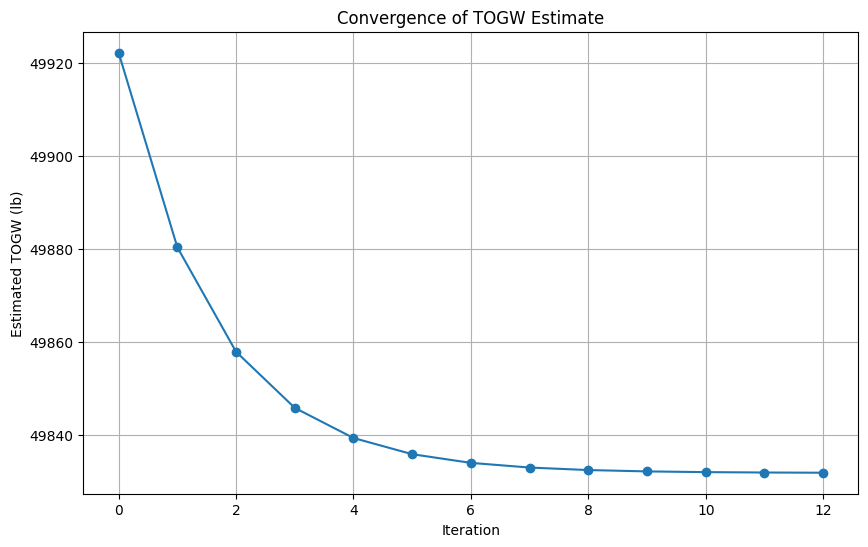

Final estimated TOGW: 49831.814440499904 lb


In [6]:
# plot the convergence history
plt.figure(figsize=(10,6))
plt.plot(W0_history, marker='o')
plt.title('Convergence of TOGW Estimate')
plt.xlabel('Iteration')
plt.ylabel('Estimated TOGW (lb)')
plt.grid()
plt.show()
print("Final estimated TOGW:", final_TOGW, "lb")

Outer Loop iteration

In [7]:
##---outer loop---
#T/W stuff ONLY
#DO NOT PUT LANDING AND TAKEOFF HERE
def outer_loop_thrust_for_one_constraint(
    S_wing_grid,
    TOGW_guess_init,
    T_total_guess_init,      # total thrust guess (all engines), lbf
    num_engines,
    S_ht, S_vt, S_wet_fuselage,
    W_crew, W_payload,
    TWfunc,
    tol_T_rel=1e-3,          
    max_iter_T=50,
    relax=1.0                # optional damping: 0.3~1.0 (use <1 if oscillation)
):
    
    T_total_converged = []
    W0_converged = []
    iter_counts = []
    T_total_history_allS = []  # list of arrays (one per S)

    for S_wing in S_wing_grid:

        T_total = T_total_guess_init
        T_hist = []

        for k in range(max_iter_T):
            # Convert total thrust to per-engine thrust for the weight model
            T_0 = T_total / num_engines

            #get the weight (W0(S_wing))
            W0, wconv, it_w, W0_hist = inner_loop_weight(
                TOGW_guess_init, S_wing, S_ht, S_vt, S_wet_fuselage,
                num_engines, W_crew, W_payload, T_0)

            #computer W0/S0
            WS = W0 / S_wing

            #find TW
            TW_req = TWfunc(WS)

            #Required total thrust
            T_req = TW_req * W0

            # Store history
            T_hist.append(T_total)

            # Check outer convergence
            if abs(T_req - T_total) / max(abs(T_total), 1e-9) < tol_T_rel:
                T_total = T_req
                break

            #update thrust to converge
            T_total = (1 - relax) * T_total + relax * T_req

        # Save results for this S
        T_total_converged.append(T_total)
        W0_converged.append(W0)
        iter_counts.append(k+1)
        T_total_history_allS.append(np.array(T_hist))

    return (np.array(T_total_converged),
            np.array(W0_converged),
            np.array(iter_counts),
            T_total_history_allS,
            W0, wconv, it_w, W0_hist)

#anthony is an idiot!!!

#Takes thrust array and outputs S array
#ONLY TAKEOFF AND LANDING
#DONT YOU DARE PUT ANYTHING ELSE IN THIS SACRED FUNCTION
def outer_loop_W_S_curves(
            Thrust_array,               #similar to other outer loop for S
            TOGW_guess_init,
            S_wing_guess_init,          #Honestly just take a swing at it
            S_ht, 
            S_vt, 
            S_wet_fuselage,
            num_engines, 
            W_crew, 
            W_payload,
            W_S_function):
    tol_T_rel=1e-3          
    max_iter_T=10 #change this so its higher
    T_grid = []         #Storing final Thrust values
    S_hist = [] # iteration history
    wing_array = []

    for i in range(0,len(Thrust_array)): #basically just a linspace of possible thrust values


        T_0 = Thrust_array[i] #Take thrust value from the array
        #S_hist_landing.append(S_wing_guess_landing)
        #S_hist_takeoff.append(S_wing_guess_takeoff)
        T_grid.append(T_0)
        
        S_hist.append(S_wing_guess_init)

        for k in range(max_iter_T):
            W0_constraint, wconv, it_w, W0_hist = inner_loop_weight(
            TOGW_guess_init, S_wing_guess_init, S_ht, S_vt, S_wet_fuselage,
            num_engines, W_crew, W_payload, T_0)

            W_S_constraint = W_S_function

            S_wing_guess = W0_constraint/W_S_constraint

            if abs(S_wing_guess - S_hist[i])/abs(S_hist[i]) < tol_T_rel:
                break

        wing_array.append(S_wing_guess)
    
    return(T_grid,wing_array)



# Set grid of wing areas to analyze
S_wing_grid = list(range(100, 1500, 2))       # Example range of wing areas to analyze
# Set grid of thrust values to analyze
T_engine_grid = list(range(0,90000,1000))     # used for the W/S driven constraint plots


TOGW_guess_init = 55000  # Initial guess for Takeoff Gross Weight in pounds
T_total_guess_init = 24000 * num_engines  # Initial guess for total thrust in pounds-force

S_wing_guess=700
print("\nStarting Inner Loop Weight Calcs for aircraft\n")


#This is the one that has been breaking
#inner_loop_weight(TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload,T_engine_grid[0])

#cruise constraint
T_cruise, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_cruise, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#SL dash constraint
T_SLdash, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_SLdash, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#SL dash ideal
T_SLdashideal, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_SLdashideal, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#30k ft dash
T_30dash, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_30dash, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#30k ft dash Ideal
T_30dashideal, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_30dashideal, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#maneuver
T_maneuver, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_maneuver, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#maneuver
T_maneuverideal, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_maneuverideal, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#ceiling
T_ceiling, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_ceiling, 
    tol_T_rel=1e-6,
    max_iter_T=200,
    relax=1)

#SEROC climb
T_climb, W0_curve, n_iter_T, T_hist_allS, W0_final, wconv_final, it_w_final, W0_hist_final = outer_loop_thrust_for_one_constraint(
    S_wing_grid=S_wing_grid,
    TOGW_guess_init=TOGW_guess_init,
    T_total_guess_init=T_total_guess_init,
    num_engines=num_engines,
    S_ht=S_ht, S_vt=S_vt, S_wet_fuselage=S_wet_fuselage,
    W_crew=W_crew, W_payload=W_payload,
    TWfunc= ds.tw_climb, 
    tol_T_rel=1e-6,
    max_iter_T=500,
    relax=0.2)

# engine_array = T_engine_grid
# S_wing_guess_init = S_wing_guess

# T_grid, wing_takeoff_array, wing_landing_array = outer_loop_W_S_curves(
#     engine_array,               #similar to other outer loop for S
#     TOGW_guess_init,
#     S_wing_guess_init,          #Honestly just take a swing at it
#     S_ht, 
#     S_vt, 
#     S_wet_fuselage,
#     num_engines, 
#     W_crew, 
#     W_payload)


#T_grid,S_W_S_array_takeoff,S_W_S_array_landing=outer_loop_W_S_curves(T_engine_grid,TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload)

T_grid,S_W_S_array_takeoff=outer_loop_W_S_curves(T_engine_grid,TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload,ds.W_S_takeoff)

T_grid,S_W_S_array_landing_runway=outer_loop_W_S_curves(T_engine_grid,TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload,ds.W_S_landing_runway)

T_grid,S_W_S_array_stall=outer_loop_W_S_curves(T_engine_grid,TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload,ds.W_S_stall)

T_grid, S_W_S_array_landing_arrestor = outer_loop_W_S_curves(T_engine_grid,TOGW_guess_init,S_wing_guess,S_ht,S_vt,S_wet_fuselage,num_engines,W_crew,W_payload,ds.W_S_landing56lb)
# Simplified Arrestor (angry)
s_L_G = (final_TOGW * cv.wf_landing * cv.V_engage**2) / (cv.g * 1.6 * cv.F_hook)

print('Your Arrestor Landing Distance is:', s_L_G, 'ft')
if s_L_G > cv.s_L_G:
    print('Your plane will fall off the ship, reduce weight/landing speed')
else:
    print('Your plane will not fall off the ship, congrats! You have avoided a multimillion dollar disaster')



Starting Inner Loop Weight Calcs for aircraft



/var/folders/9p/bzxxtlj556zbl50hvqr5j2y80000gn/T/ipykernel_7687/1563905672.py:43: RuntimeWarning: overflow encountered in scalar multiply
  T_req = TW_req * W0
/var/folders/9p/bzxxtlj556zbl50hvqr5j2y80000gn/T/ipykernel_7687/1620151696.py:81: RuntimeWarning: invalid value encountered in scalar divide
  delta = abs(W0_new - TOGW_guess) / max(abs(W0_new), 1e-9)
/var/folders/9p/bzxxtlj556zbl50hvqr5j2y80000gn/T/ipykernel_7687/1563905672.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(T_req - T_total) / max(abs(T_total), 1e-9) < tol_T_rel:
/var/folders/9p/bzxxtlj556zbl50hvqr5j2y80000gn/T/ipykernel_7687/1563905672.py:54: RuntimeWarning: invalid value encountered in scalar multiply
  T_total = (1 - relax) * T_total + relax * T_req


Your Arrestor Landing Distance is: 241.8615637730463 ft
Your plane will not fall off the ship, congrats! You have avoided a multimillion dollar disaster


Comparable Aircraft

In [51]:
#Comparable Aircraft T/S
T_J39C_dry=12000 #lbf
T_J39C_wet=18000 #lbf
S_J39C=320 #ft^2

T_Su33_dry=33400 #lbf
T_Su33_wet=56400 #lbf
S_Su33=730 #ft^2

#I didnt find dry thrust numbers for Su-34
T_Su34_wet=60000 #lbf
S_Su34=667.8 #ft^2

T_Typhoon_dry=27000 #lbf
T_Typhoon_wet=40400 #lbf
S_Typhoon=551.1 #ft^2

T_Rafale_M_dry=22500 #lbf
T_Rafale_M_wet=34000 #lbf
S_Rafale_M=492 #ft^2

T_F18_E_dry=26000 #lbf
T_F18_E_wet=44000 #lbf
S_F18_E_M=500 #ft^2

T_F35C_dry = 28000 #lbf
T_F35C_wet = 43000 #lbf
S_F35C = 668 #ft^2

T_F16C_dry = 17000 #lbf
T_F16C_wet = 29000 #lbf
S_F16C = 300 #ft^2

T_F22A_dry = 52000 #lbf
T_F22A_wet = 70000 #lbf
S_F22A = 840 #ft^2

T_Gripen_dry = 13000 #lbf
T_Gripen_wet = 22000 #lbf
S_Gripen = 320 #ft^2

T_F15C_dry = 30000 #lbf
T_F15C_wet = 48000 #lbf
S_F15C = 608 #ft^2

Plotting Constraints

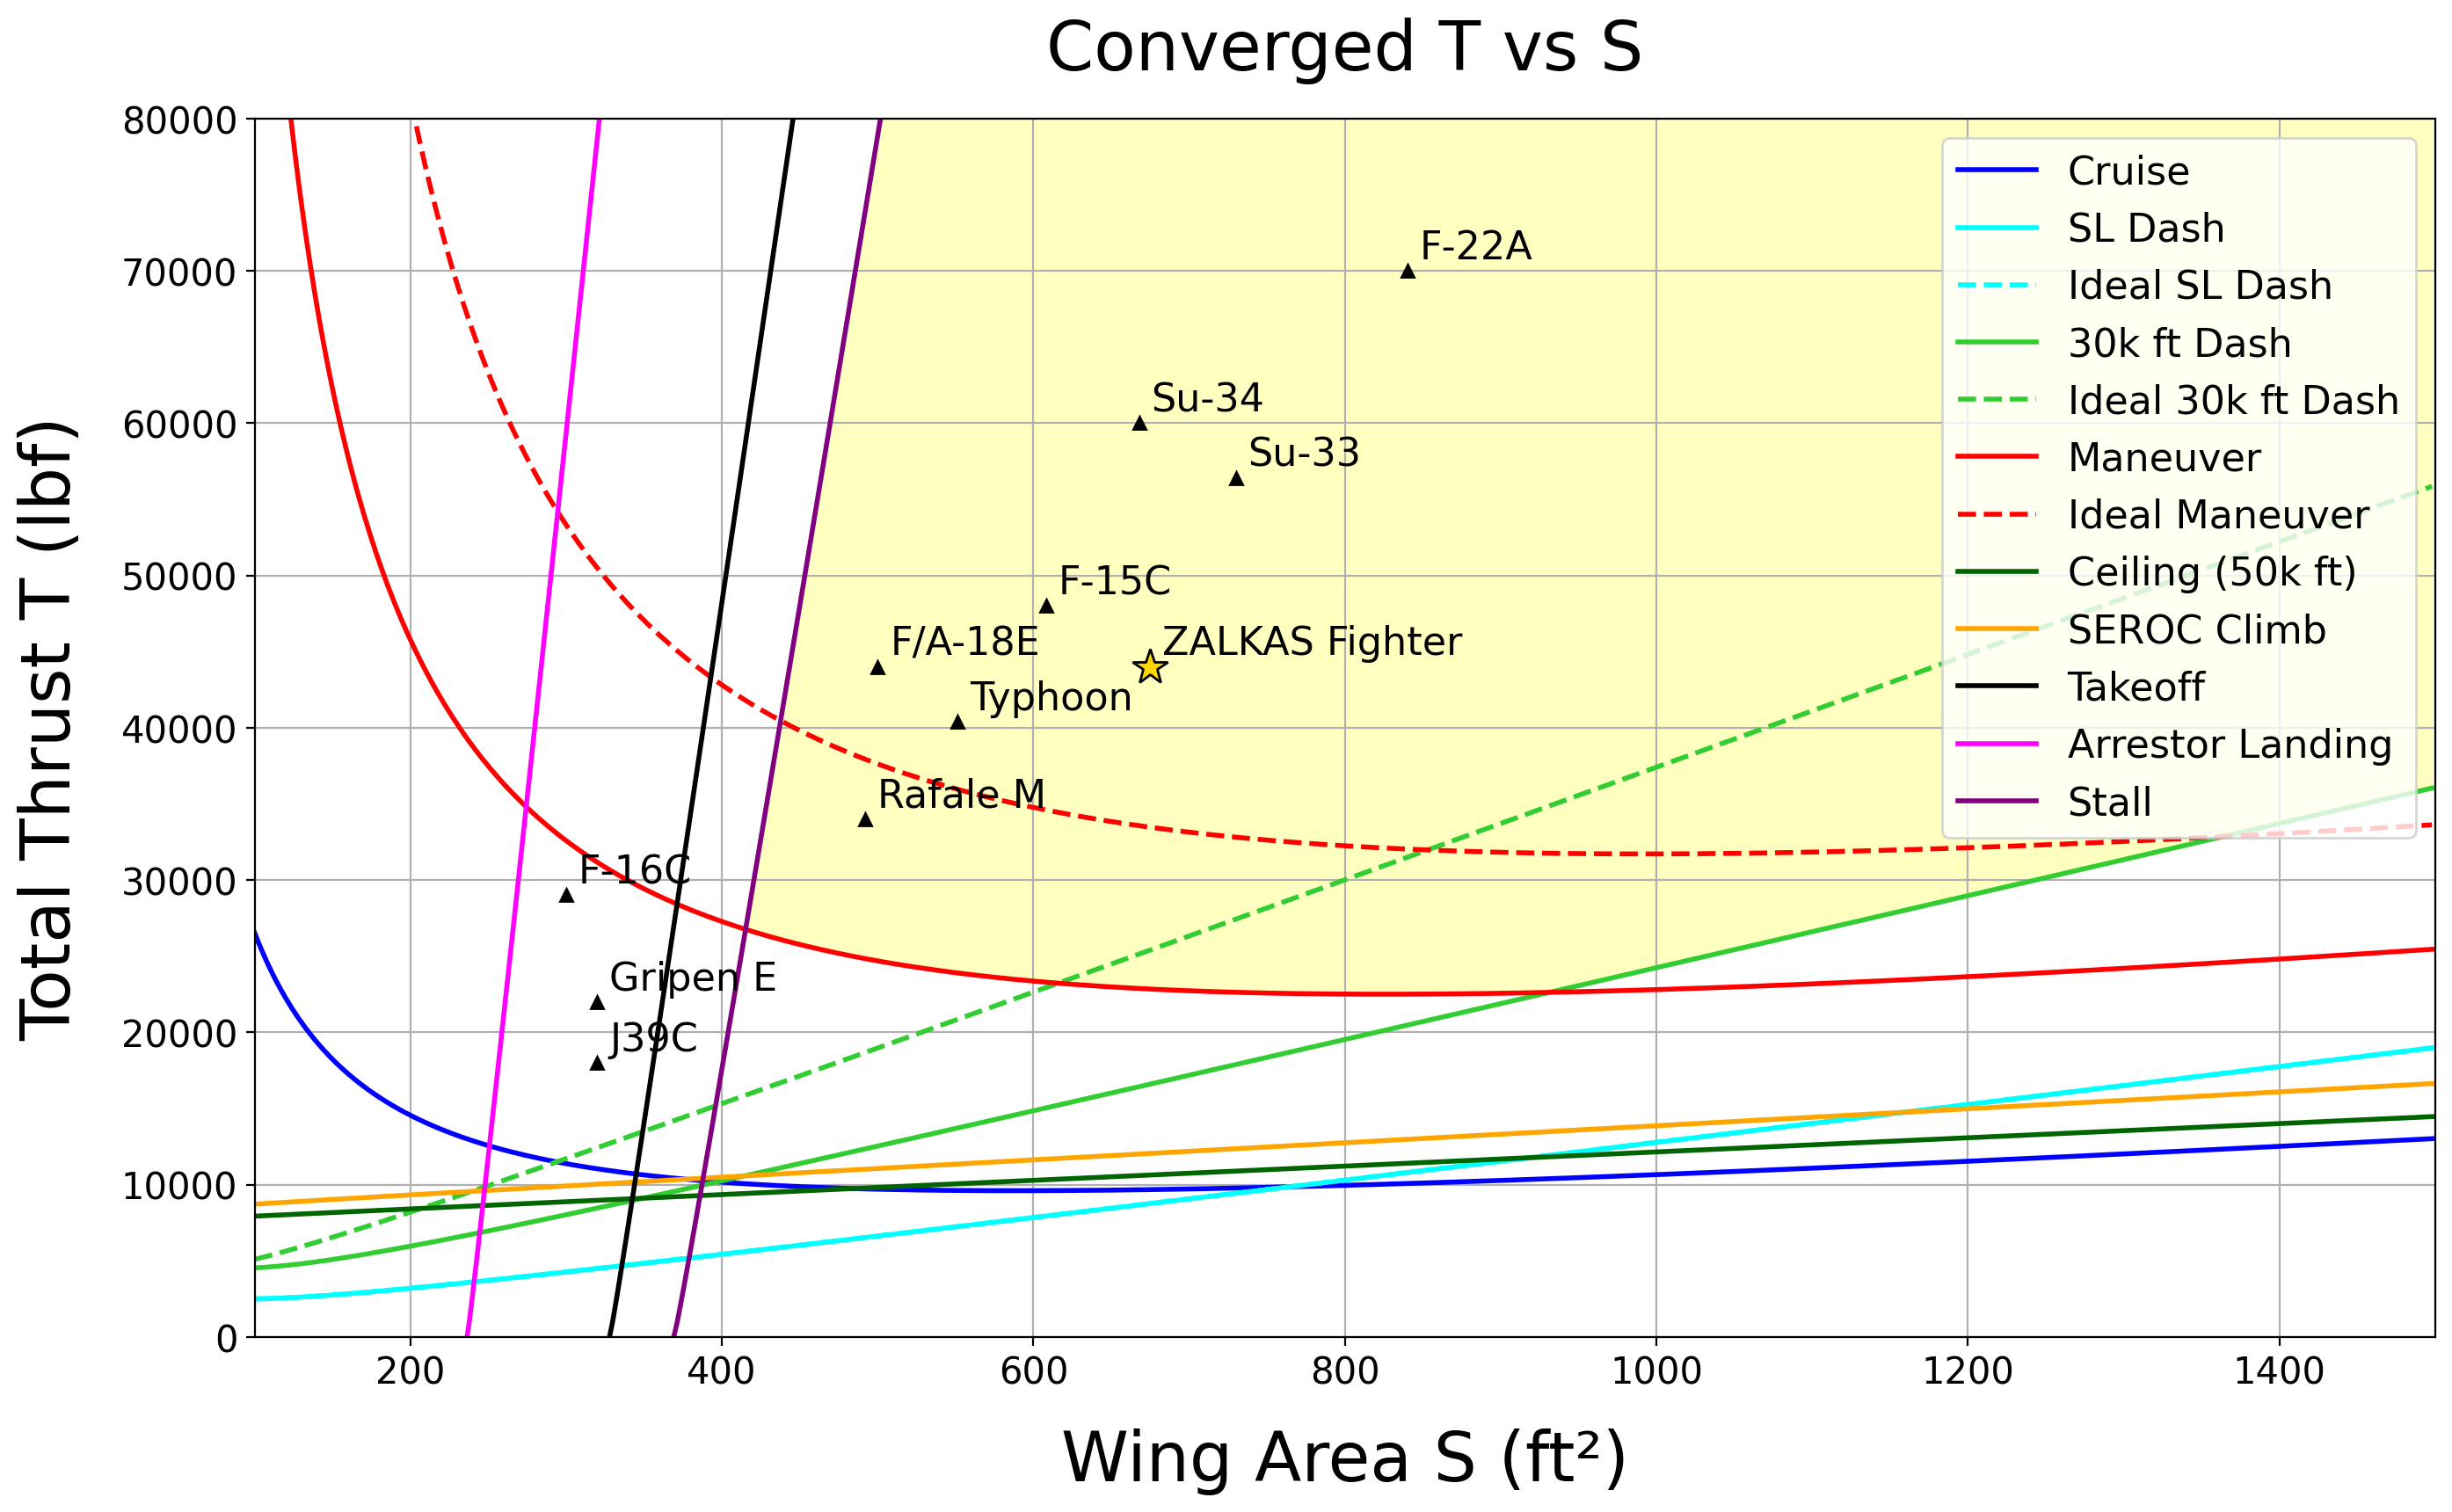

In [56]:
fig = plt.figure(figsize=(16,9))
plt.title('Converged T vs S',fontsize=28, pad = 20)
plt.xlabel("Wing Area S (ft²)",fontsize=28, labelpad=15)
plt.ylabel("Total Thrust T (lbf)",fontsize=28, labelpad=15)
plt.plot(S_wing_grid, T_cruise, color='blue', linewidth=2, label='Cruise')
plt.plot(S_wing_grid, T_SLdash, color='cyan', linewidth=2, label='SL Dash')
plt.plot(S_wing_grid, T_SLdashideal, color='cyan', linewidth=2,linestyle='--', label='Ideal SL Dash')
plt.plot(S_wing_grid, T_30dash, color='limegreen',  linewidth=2,label='30k ft Dash')
plt.plot(S_wing_grid, T_30dashideal, color='limegreen',  linewidth=2, linestyle='--', label='Ideal 30k ft Dash')
plt.plot(S_wing_grid, T_maneuver, color='red', linewidth=2,label='Maneuver')
plt.plot(S_wing_grid, T_maneuverideal, color='red', linewidth=2, linestyle='--', label='Ideal Maneuver')
plt.plot(S_wing_grid, T_ceiling, color='darkgreen', linewidth=2, label='Ceiling (50k ft)')
plt.plot(S_wing_grid, T_climb, color='orange', linewidth=2, label='SEROC Climb')
plt.plot(S_W_S_array_takeoff, T_grid, color='black', linewidth=2, label = 'Takeoff')
#plt.plot(S_W_S_array_landing_runway, T_grid, color='magenta', linewidth=2, linestyle='--', label = 'Landing on 3000ft Runway')
plt.plot(S_W_S_array_landing_arrestor, T_grid, color='magenta', linewidth=2, label = 'Arrestor Landing')
plt.plot(S_W_S_array_stall, T_grid, color='purple', linewidth=2, label = 'Stall')

S_main = np.array(S_wing_grid)
T_top = 100000
T_lower_curve = np.array(T_maneuver)

# Sort runway landing data
idx = np.argsort(T_grid)
T_land_sorted = np.array(T_grid)[idx]
S_land_runway_sorted = np.array(S_W_S_array_landing_runway)[idx]

# Sort arrestor landing data
idx = np.argsort(T_grid)
T_land_sorted = np.array(T_grid)[idx]
S_land_arrestor_sorted = np.array(S_W_S_array_landing_arrestor)[idx]

# Sort 30k dash data
idx30 = np.argsort(T_30dash)
T_30_sorted = np.array(T_30dash)[idx30]
S_30_sorted = np.array(S_main)[idx30]

# Sort stall data
idx_stall = np.argsort(T_grid)
T_stall_sorted = np.array(T_grid)[idx_stall]
S_stall_sorted = np.array(S_W_S_array_stall)[idx_stall]
# Create mesh
S_mesh, T_mesh = np.meshgrid(S_main, np.linspace(0, T_top, 400))

# Interpolate runway landing S requirement at each T (left boundary)
S_landing_runway_required = np.interp(T_mesh, T_land_sorted, S_land_runway_sorted)

# Interpolate arrestor landing S requirement at each T 
S_landing_arrestor_required = np.interp(T_mesh, T_land_sorted, S_land_arrestor_sorted)

#interpolate stall S req
S_stall_required = np.interp(T_mesh, T_stall_sorted, S_stall_sorted)

# Interpolate 30k dash  S at each T (right boundary)
S_30_required = np.interp(T_mesh, T_30_sorted, S_30_sorted)

# Mask: above maneuver, right of landing, left of 30k dash ideal
mask = (
    (T_mesh >= np.interp(S_mesh, S_main, T_lower_curve)) &  # above maneuver
    (S_mesh >= (S_stall_required)) &  
    (S_mesh <= S_30_required)                               # left of 30k dash ideal
)



# Shade
plt.contourf(
    S_mesh,
    T_mesh,
    mask,
    levels=[0.5, 1],
    alpha=0.25,
    colors=['yellow']
)

#comparable aircraft points
aircraft_points = [
    (S_J39C, T_J39C_wet, "J39C"),
    (S_Su33, T_Su33_wet, "Su-33"),
    (S_Su34, T_Su34_wet, "Su-34"),
    (S_Typhoon, T_Typhoon_wet, "Typhoon"),
    (S_Rafale_M, T_Rafale_M_wet, "Rafale M"),
    (S_F18_E_M, T_F18_E_wet, "F/A-18E"),
    #(S_F35C, T_F35C_wet, "F35-C"),
    (S_F16C, T_F16C_wet, "F-16C"),
    (S_F22A, T_F22A_wet, "F-22A"),
    (S_Gripen, T_Gripen_wet, "Gripen E"),
    (S_F15C, T_F15C_wet, "F-15C")]
#plots and labels comparable aircraft
for S, T, name in aircraft_points:
    plt.plot(S, T, marker='^', markersize=5, color='black')
    plt.annotate(name, (S, T), xytext=(5,5), textcoords='offset points',fontsize=16)




plt.plot(S_ZALKAS, T_ZALKAS, marker='*', color='gold', markersize=15,  markeredgecolor='black', zorder=5)
plt.annotate('ZALKAS Fighter', (S_ZALKAS, T_ZALKAS), xytext=(5,5), textcoords='offset points',fontsize=16)

plt.legend(loc='upper right',fontsize=16)
plt.ylim(0,80000)
plt.xlim(100,1500)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

fig.set_dpi(200)

plt.grid()
plt.show()


(100.0, 1500.0)

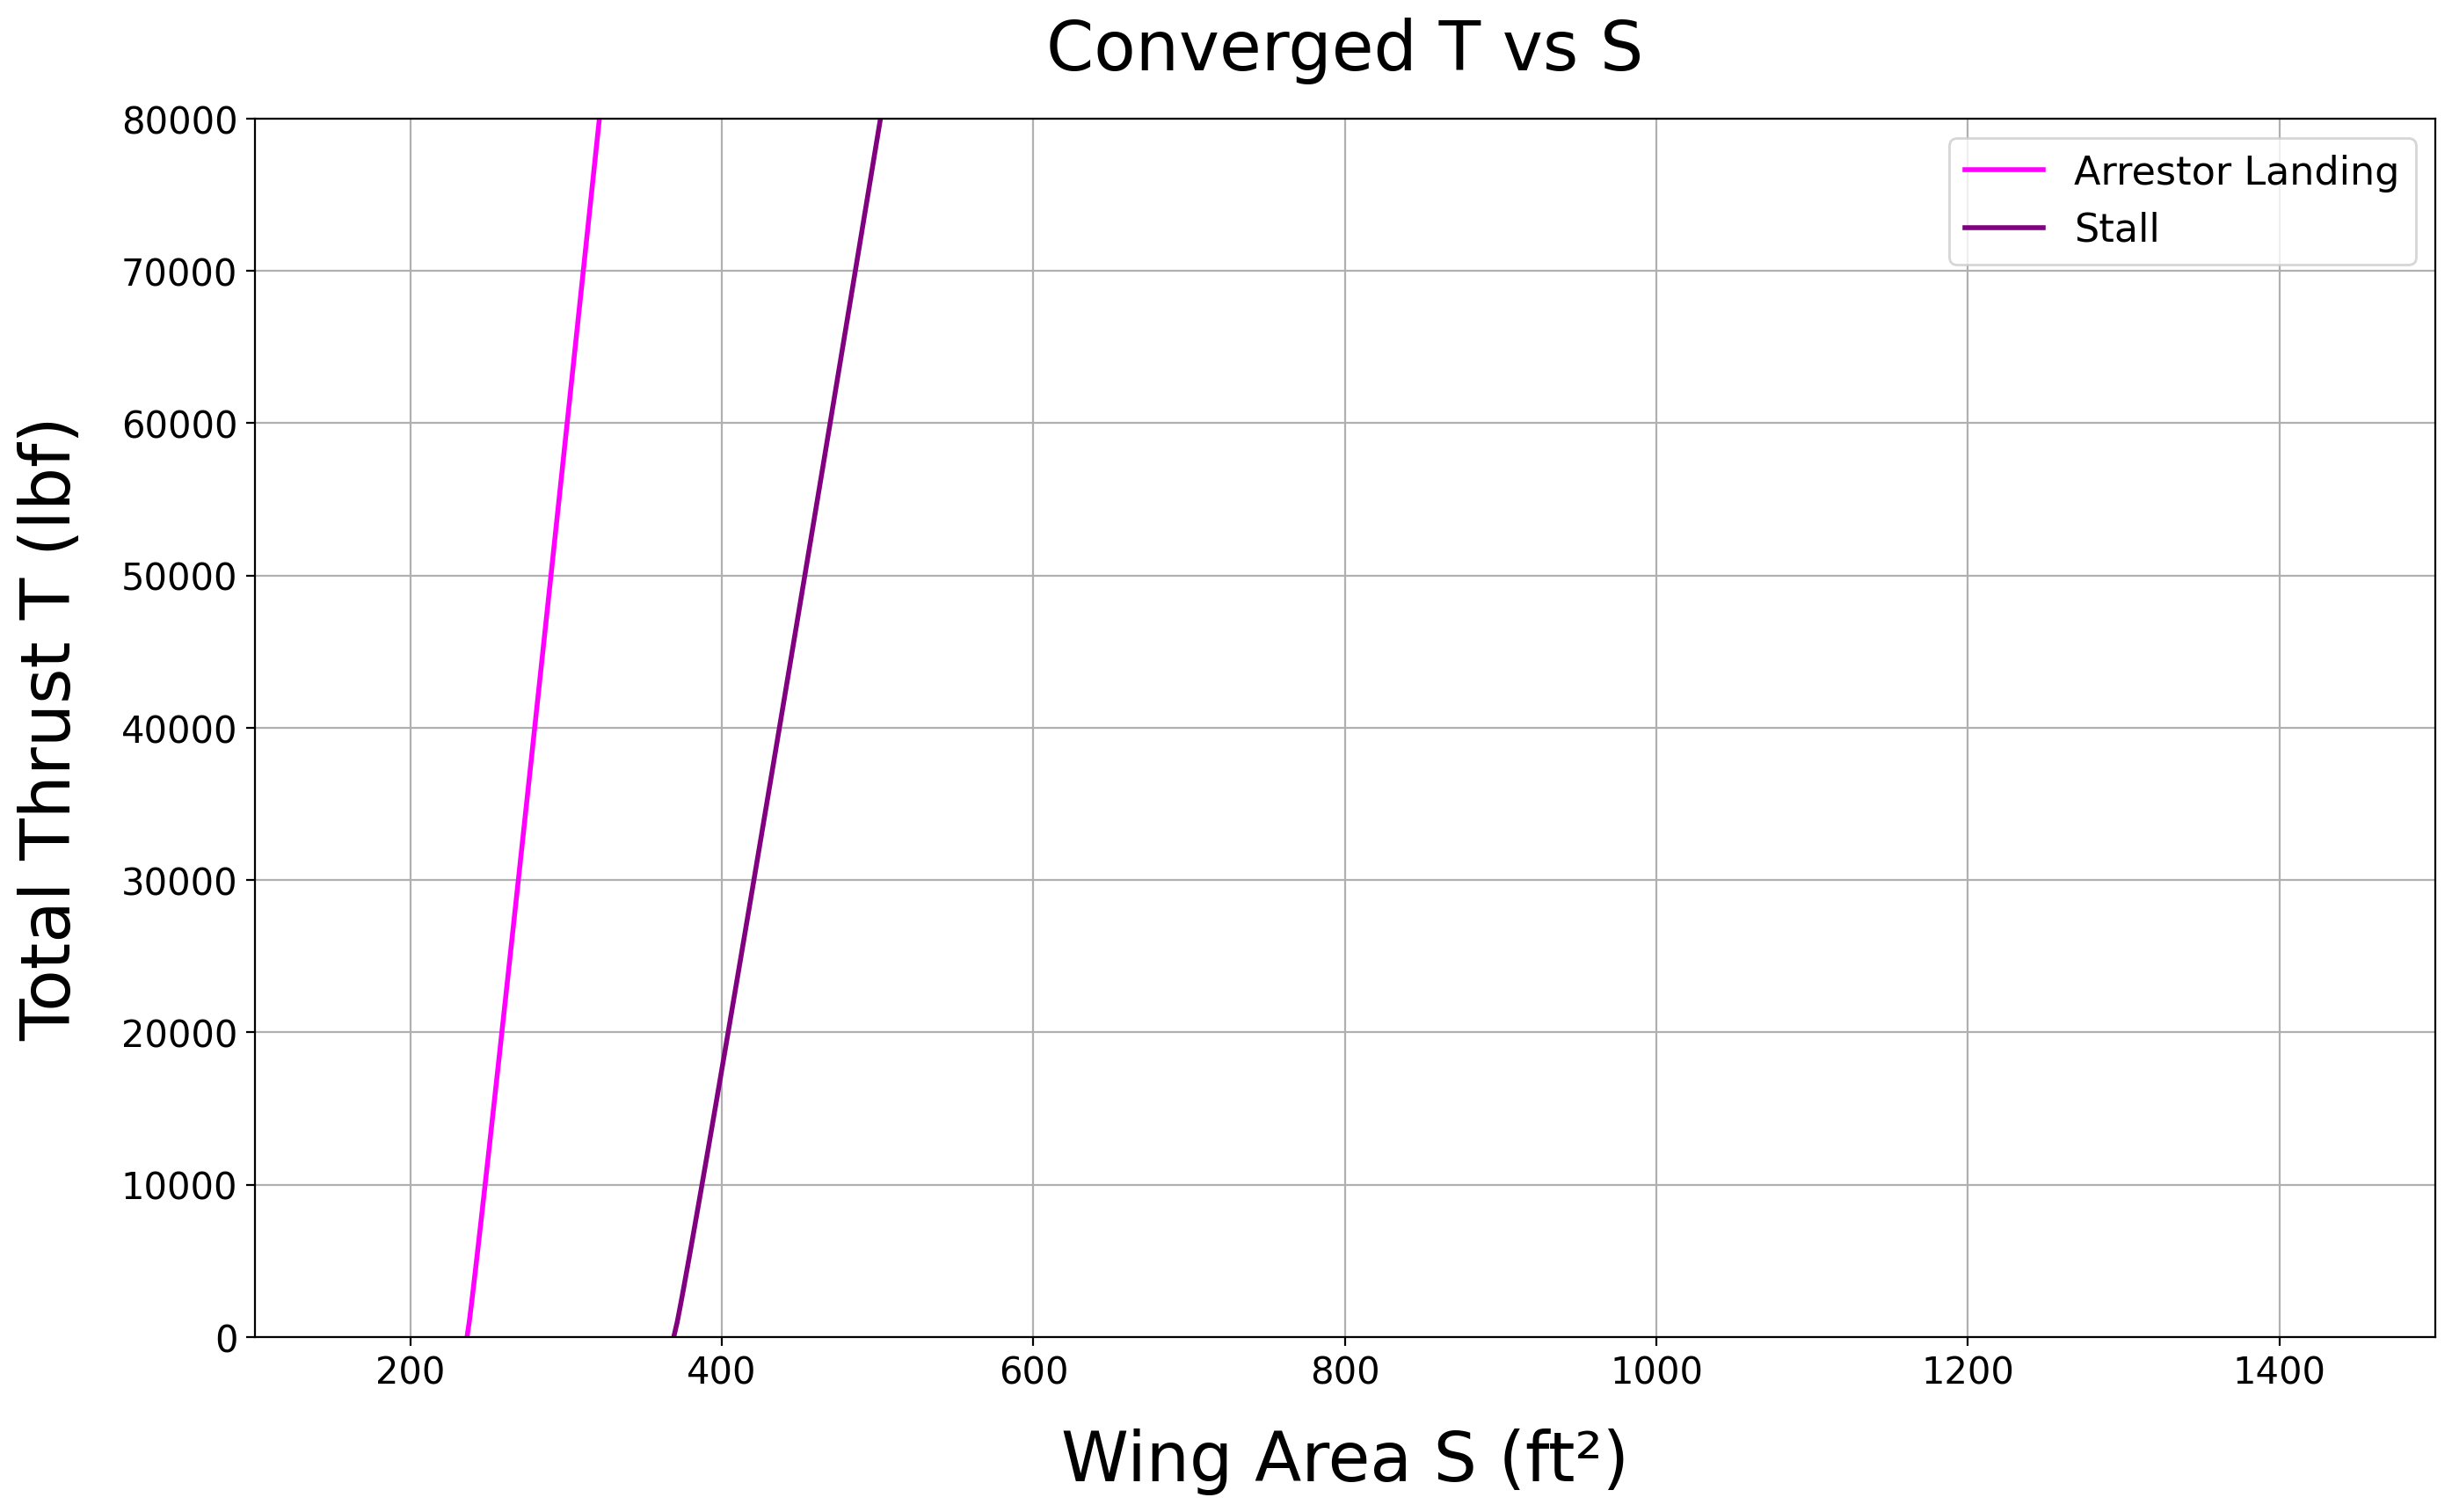

In [55]:
fig = plt.figure(figsize=(16,9))
plt.title('Converged T vs S',fontsize=28, pad = 20)
plt.xlabel("Wing Area S (ft²)",fontsize=28, labelpad=15)
plt.ylabel("Total Thrust T (lbf)",fontsize=28, labelpad=15)
# plt.plot(S_wing_grid, T_cruise, color='blue', linewidth=2, label='Cruise')
# plt.plot(S_wing_grid, T_SLdash, color='cyan', linewidth=2, label='SL Dash')
# plt.plot(S_wing_grid, T_SLdashideal, color='cyan', linewidth=2,linestyle='--', label='Ideal SL Dash')
# plt.plot(S_wing_grid, T_30dash, color='limegreen',  linewidth=2,label='30k ft Dash')
# plt.plot(S_wing_grid, T_30dashideal, color='limegreen',  linewidth=2, linestyle='--', label='Ideal 30k ft Dash')
# plt.plot(S_wing_grid, T_maneuver, color='red', linewidth=2,label='Maneuver')
# plt.plot(S_wing_grid, T_maneuverideal, color='red', linewidth=2, linestyle='--', label='Ideal Maneuver')
# plt.plot(S_wing_grid, T_ceiling, color='darkgreen', linewidth=2, label='Ceiling (50k ft)')
# plt.plot(S_wing_grid, T_climb, color='orange', linewidth=2, label='SEROC Climb')
# plt.plot(S_W_S_array_takeoff, T_grid, color='black', linewidth=2, label = 'Takeoff')
#plt.plot(S_W_S_array_landing_runway, T_grid, color='magenta', linewidth=2, linestyle='--', label = 'Landing on 3000ft Runway')
plt.plot(S_W_S_array_landing_arrestor, T_grid, color='magenta', linewidth=2, label = 'Arrestor Landing')
plt.plot(S_W_S_array_stall, T_grid, color='purple', linewidth=2, label = 'Stall')

S_main = np.array(S_wing_grid)
T_top = 100000
T_lower_curve = np.array(T_maneuver)

# Sort runway landing data
idx = np.argsort(T_grid)
T_land_sorted = np.array(T_grid)[idx]
S_land_runway_sorted = np.array(S_W_S_array_landing_runway)[idx]

# Sort arrestor landing data
idx = np.argsort(T_grid)
T_land_sorted = np.array(T_grid)[idx]
S_land_arrestor_sorted = np.array(S_W_S_array_landing_arrestor)[idx]

# Sort 30k dash data
idx30 = np.argsort(T_30dash)
T_30_sorted = np.array(T_30dash)[idx30]
S_30_sorted = np.array(S_main)[idx30]

# Sort stall data
idx_stall = np.argsort(T_grid)
T_stall_sorted = np.array(T_grid)[idx_stall]
S_stall_sorted = np.array(S_W_S_array_stall)[idx_stall]
# Create mesh
S_mesh, T_mesh = np.meshgrid(S_main, np.linspace(0, T_top, 400))

# Interpolate runway landing S requirement at each T (left boundary)
S_landing_runway_required = np.interp(T_mesh, T_land_sorted, S_land_runway_sorted)

# Interpolate arrestor landing S requirement at each T 
S_landing_arrestor_required = np.interp(T_mesh, T_land_sorted, S_land_arrestor_sorted)

#interpolate stall S req
S_stall_required = np.interp(T_mesh, T_stall_sorted, S_stall_sorted)

# Interpolate 30k dash  S at each T (right boundary)
S_30_required = np.interp(T_mesh, T_30_sorted, S_30_sorted)

# Mask: above maneuver, right of landing, left of 30k dash ideal
mask = (
    (T_mesh >= np.interp(S_mesh, S_main, T_lower_curve)) &  # above maneuver
    (S_mesh >= (S_stall_required)) &  
    (S_mesh <= S_30_required)                               # left of 30k dash ideal
)



# Shade
# plt.contourf(
#     S_mesh,
#     T_mesh,
#     mask,
#     levels=[0.5, 1],
#     alpha=0.25,
#     colors=['yellow']
# )

#comparable aircraft points
# aircraft_points = [
#     (S_J39C, T_J39C_wet, "J39C"),
#     # (S_Su33, T_Su33_wet, "Su-33"),
#     (S_Su34, T_Su34_wet, "Su-34"),
#     (S_Typhoon, T_Typhoon_wet, "Typhoon"),
#     (S_Rafale_M, T_Rafale_M_wet, "Rafale M"),
#     (S_F18_E_M, T_F18_E_wet, "F/A-18E"),
#     #(S_F35C, T_F35C_wet, "F35-C"),
#     (S_F16C, T_F16C_wet, "F-16C"),
#     # (S_F22A, T_F22A_wet, "F-22A"),
#     (S_Gripen, T_Gripen_wet, "Gripen E"),
#     (S_F15C, T_F15C_wet, "F-15C")]
# #plots and labels comparable aircraft
# for S, T, name in aircraft_points:
#     plt.plot(S, T, marker='^', markersize=5, color='black')
#     plt.annotate(name, (S, T), xytext=(5,5), textcoords='offset points',fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# plt.plot(S_ZALKAS, T_ZALKAS, marker='*', color='gold', markersize=15,  markeredgecolor='black', zorder=5)
# plt.annotate('ZALKAS Fighter', (S_ZALKAS, T_ZALKAS), xytext=(5,5), textcoords='offset points',fontsize=16)
plt.grid(True)
plt.legend(loc='upper right',fontsize=16)

fig.set_dpi(200)

plt.ylim(0,80000)
plt.xlim(100,1500)
